## 1.1 Fundamentos de la Técnica

La **Regresión Logística** es un algoritmo de clasificación supervisada utilizado para predecir la probabilidad de que una instancia pertenezca a una clase particular. A diferencia de la regresión lineal, la regresión logística modela probabilidades usando la función sigmoide, que mapea cualquier valor real al rango [0,1].

 **Características principales:**
 - Algoritmo de clasificación (binaria o multiclase)
 - Utiliza la función sigmoide para transformar salidas
 - Basado en probabilidades
 - Fácil de implementar e interpretar

 ## 1.2 Modelo Matemático

 **Función de hipótesis:**
\begin{aligned}
h_\theta(x) = \sigma(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}
\end{aligned}

 **Donde:**
 - \(\sigma(z)\) es la función sigmoide
 - \(\theta\) son los parámetros del modelo
 - \(x\) son las características de entrada

 **Función de costo (Log Loss):**
\begin{aligned}
J(\theta) = -\frac{1}{m} \sum_{i=1}^{m}
\left[
y^{(i)} \log\left(h_\theta(x^{(i)})\right) + (1-y^{(i)}) \log\left(1-h_\theta(x^{(i)})\right)
\right]
\end{aligned}

 ## 1.3 Librerías y Funciones

 **Principales librerías:**
 - `scikit-learn`: Implementación de modelos de machine learning
 - `pandas`: Manipulación de datos
 - `numpy`: Operaciones matemáticas
 - `matplotlib` y `seaborn`: Visualización

 ## Librerías y Funciones Utilizadas

**pandas**
- Manipulación y análisis de datos estructurados
- DataFrames para trabajar con datos tabulares
- Funciones para estadísticas descriptivas

**numpy**
- Operaciones matemáticas y numéricas
- Arrays multidimensionales
- Funciones estadísticas básicas

**matplotlib.pyplot**
- Creación de gráficos y visualizaciones
- Gráficos de dispersión, histogramas, barras
- Personalización de figuras

**seaborn**
- Visualizaciones estadísticas más avanzadas
- Mapas de calor para matrices de confusión
- Estilos predefinidos para gráficos

**scikit-learn (sklearn)**
- Machine learning en Python
- Implementación de algoritmos
- Herramientas de preprocesamiento y evaluación

### Funciones Específicas de scikit-learn

**sklearn.datasets**
- `load_iris()`: Dataset de flores Iris (clásico)

**sklearn.model_selection**
- `train_test_split()`: División de datos en entrenamiento y prueba
- `cross_val_score()`: Validación cruzada para evaluación robusta

**sklearn.linear_model**
- `LogisticRegression`: Implementación de regresión logística
- `LogisticRegressionCV`: Regresión logística con validación cruzada integrada

**sklearn.preprocessing**
- `StandardScaler`: Estandarización de características (media=0, varianza=1)

**sklearn.metrics**
- `confusion_matrix`: Matriz de confusión para evaluación
- `accuracy_score`: Cálculo de exactitud del modelo
- `classification_report`: Reporte completo de métricas

### Funciones Personalizadas

**predict_class()**
- Recibe nuevos patrones para clasificar
- Aplica preprocesamiento automático
- Retorna clase predicha y probabilidades

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

print("Librerías importadas correctamente")

Librerías importadas correctamente


 ## 1.4 Pipeline de Machine Learning

 ### Preprocesamiento y Análisis Exploratorio

Cargar dataset de ejemplo (Iris para clasificación binaria)

In [2]:
from sklearn.datasets import load_iris

# Cargar datos
iris = load_iris()
X = iris.data
y = iris.target

# Convertir a problema binario (clase 0 vs clase 1)
binary_mask = y < 2
X_binary = X[binary_mask]
y_binary = y[binary_mask]

# Crear DataFrame para análisis
df = pd.DataFrame(X_binary, columns=iris.feature_names)
df['target'] = y_binary

print("Dataset Cargado - Información General")
print("=" * 50)
print(f"Dimensiones del dataset: {df.shape}")
print(f"Número de características: {len(iris.feature_names)}")
print(f"Clases: {np.unique(y_binary)}")

📊 Dataset Cargado - Información General
Dimensiones del dataset: (100, 5)
Número de características: 4
Clases: [0 1]


# Análisis estadístico descriptivo

In [3]:
print("\n📈 Análisis Estadístico Descriptivo")
print("=" * 50)
print(df.describe())


📈 Análisis Estadístico Descriptivo
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         100.000000        100.000000         100.000000   
mean            5.471000          3.099000           2.861000   
std             0.641698          0.478739           1.449549   
min             4.300000          2.000000           1.000000   
25%             5.000000          2.800000           1.500000   
50%             5.400000          3.050000           2.450000   
75%             5.900000          3.400000           4.325000   
max             7.000000          4.400000           5.100000   

       petal width (cm)      target  
count        100.000000  100.000000  
mean           0.786000    0.500000  
std            0.565153    0.502519  
min            0.100000    0.000000  
25%            0.200000    0.000000  
50%            0.800000    0.500000  
75%            1.300000    1.000000  
max            1.800000    1.000000  


# Información adicional sobre distribución de clases

In [4]:
print("\n🎯 Distribución de Clases")
print("=" * 50)
class_distribution = df['target'].value_counts()
print(class_distribution)
print(f"\nProporción de clases:\n{class_distribution / len(df)}")


🎯 Distribución de Clases
target
0    50
1    50
Name: count, dtype: int64

Proporción de clases:
target
0    0.5
1    0.5
Name: count, dtype: float64


# Gráfico de dispersión (Scatter Plot)

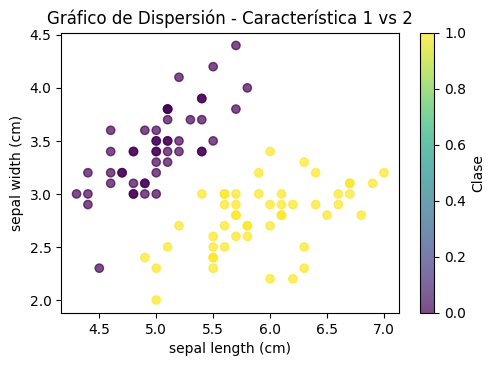

In [7]:
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
scatter = plt.scatter(X_binary[:, 0], X_binary[:, 1], c=y_binary, cmap='viridis', alpha=0.7)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title('Gráfico de Dispersión - Característica 1 vs 2')
plt.colorbar(scatter, label='Clase')

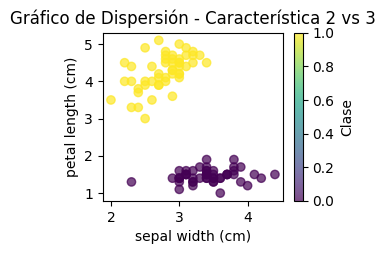

In [8]:
plt.subplot(2, 2, 2)
scatter = plt.scatter(X_binary[:, 1], X_binary[:, 2], c=y_binary, cmap='viridis', alpha=0.7)
plt.xlabel(iris.feature_names[1])
plt.ylabel(iris.feature_names[2])
plt.title('Gráfico de Dispersión - Característica 2 vs 3')
plt.colorbar(scatter, label='Clase')

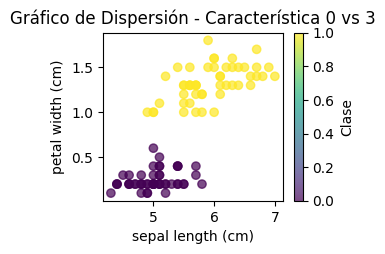

In [9]:
plt.subplot(2, 2, 3)
scatter = plt.scatter(X_binary[:, 0], X_binary[:, 3], c=y_binary, cmap='viridis', alpha=0.7)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[3])
plt.title('Gráfico de Dispersión - Característica 0 vs 3')
plt.colorbar(scatter, label='Clase')

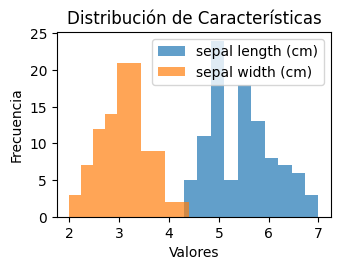

In [10]:
# Histograma de características
plt.subplot(2, 2, 4)
plt.hist(X_binary[:, 0], alpha=0.7, label=iris.feature_names[0])
plt.hist(X_binary[:, 1], alpha=0.7, label=iris.feature_names[1])
plt.xlabel('Valores')
plt.ylabel('Frecuencia')
plt.title('Distribución de Características')
plt.legend()

plt.tight_layout()
plt.show()

### División y Preparación de Datos

In [11]:
# Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_binary, y_binary, test_size=0.3, random_state=42, stratify=y_binary
)

# Escalar características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos preparados correctamente")
print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de prueba: {X_test.shape}")

Datos preparados correctamente
Tamaño del conjunto de entrenamiento: (70, 4)
Tamaño del conjunto de prueba: (30, 4)


### Entrenamiento del Modelo

In [12]:
# Crear y entrenar el modelo de regresión logística
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

print("Modelo entrenado correctamente")
print(f"Coeficientes: {model.coef_}")
print(f"Intercepto: {model.intercept_}")

Modelo entrenado correctamente
Coeficientes: [[ 0.84579129 -1.00398344  1.39479409  1.4247247 ]]
Intercepto: [0.19790844]


### Función de Predicción

In [13]:
def predict_class(model, scaler, new_sample):
    """
    Función para predecir la clase de un nuevo patrón

    Parameters:
    - model: Modelo de regresión logística entrenado
    - scaler: Scaler utilizado para preprocesamiento
    - new_sample: Array con las características del nuevo patrón

    Returns:
    - Clase predicha y probabilidades
    """
    # Escalar el nuevo patrón
    new_sample_scaled = scaler.transform([new_sample])

    # Predecir clase
    predicted_class = model.predict(new_sample_scaled)[0]

    # Obtener probabilidades
    probabilities = model.predict_proba(new_sample_scaled)[0]

    return predicted_class, probabilities


### Probar la función de predicción con ejemplos

In [14]:
print("Probando función de predicción:")
print("=" * 40)

# Ejemplo 1
sample_1 = [5.1, 3.5, 1.4, 0.2]  # Debería ser clase 0
pred_class_1, probs_1 = predict_class(model, scaler, sample_1)
print(f"Ejemplo 1: {sample_1}")
print(f"Clase predicha: {pred_class_1}")
print(f"Probabilidades: [Clase 0: {probs_1[0]:.3f}, Clase 1: {probs_1[1]:.3f}]")
print()

# Ejemplo 2
sample_2 = [6.7, 3.0, 5.2, 2.3]  # Debería ser clase 1 (modificado para clasificación binaria)
pred_class_2, probs_2 = predict_class(model, scaler, sample_2)
print(f"Ejemplo 2: {sample_2}")
print(f"Clase predicha: {pred_class_2}")
print(f"Probabilidades: [Clase 0: {probs_2[0]:.3f}, Clase 1: {probs_2[1]:.3f}]")

Probando función de predicción:
Ejemplo 1: [5.1, 3.5, 1.4, 0.2]
Clase predicha: 0
Probabilidades: [Clase 0: 0.983, Clase 1: 0.017]

Ejemplo 2: [6.7, 3.0, 5.2, 2.3]
Clase predicha: 1
Probabilidades: [Clase 0: 0.000, Clase 1: 1.000]


## 1.5 Evaluación del Modelo

### Matriz de Confusión

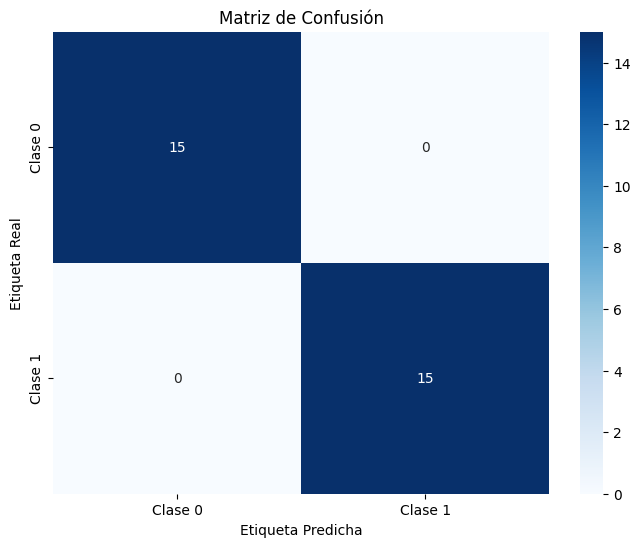

Análisis de la Matriz de Confusión:
Verdaderos Positivos (TP): 15
Verdaderos Negativos (TN): 15
Falsos Positivos (FP): 0
Falsos Negativos (FN): 0


In [15]:
# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test_scaled)

# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Visualizar matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Clase 0', 'Clase 1'],
            yticklabels=['Clase 0', 'Clase 1'])
plt.title('Matriz de Confusión')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.show()

print("Análisis de la Matriz de Confusión:")
print(f"Verdaderos Positivos (TP): {cm[1, 1]}")
print(f"Verdaderos Negativos (TN): {cm[0, 0]}")
print(f"Falsos Positivos (FP): {cm[0, 1]}")
print(f"Falsos Negativos (FN): {cm[1, 0]}")

### Métricas de Evaluación

In [16]:
# Calcular accuracy
accuracy = accuracy_score(y_test, y_pred)

print("📈 Métricas de Evaluación")
print("=" * 30)
print(f"Accuracy (Exactitud): {accuracy:.4f} ({accuracy*100:.2f}%)")

# Reporte de clasificación completo
print("\n📋 Reporte de Clasificación:")
print("=" * 40)
print(classification_report(y_test, y_pred, target_names=['Clase 0', 'Clase 1']))

📈 Métricas de Evaluación
Accuracy (Exactitud): 1.0000 (100.00%)

📋 Reporte de Clasificación:
              precision    recall  f1-score   support

     Clase 0       1.00      1.00      1.00        15
     Clase 1       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [18]:
# Métricas adicionales calculadas manualmente
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("\nMétricas Adicionales:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")


Métricas Adicionales:
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000


### Visualización de Resultados

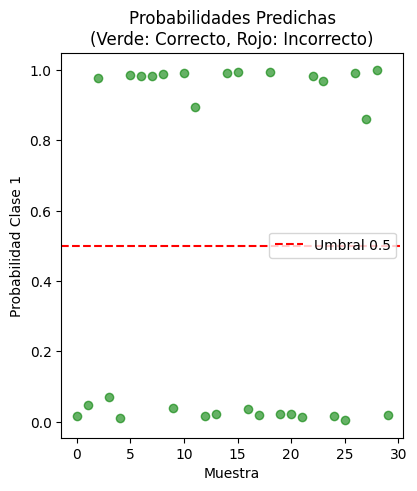

In [19]:
# Gráfico de probabilidades predichas
y_pred_proba = model.predict_proba(X_test_scaled)

plt.figure(figsize=(15, 5))

# Gráfico 1: Probabilidades por clase
plt.subplot(1, 3, 1)
for i in range(len(y_test)):
    color = 'green' if y_pred[i] == y_test[i] else 'red'
    plt.scatter(i, y_pred_proba[i, 1], color=color, alpha=0.6)
plt.axhline(y=0.5, color='red', linestyle='--', label='Umbral 0.5')
plt.xlabel('Muestra')
plt.ylabel('Probabilidad Clase 1')
plt.title('Probabilidades Predichas\n(Verde: Correcto, Rojo: Incorrecto)')
plt.legend()

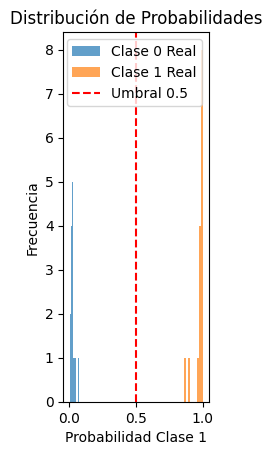

In [20]:
# Gráfico 2: Distribución de probabilidades
plt.subplot(1, 3, 2)
plt.hist(y_pred_proba[y_test == 0, 1], alpha=0.7, label='Clase 0 Real', bins=10)
plt.hist(y_pred_proba[y_test == 1, 1], alpha=0.7, label='Clase 1 Real', bins=10)
plt.axvline(x=0.5, color='red', linestyle='--', label='Umbral 0.5')
plt.xlabel('Probabilidad Clase 1')
plt.ylabel('Frecuencia')
plt.title('Distribución de Probabilidades')
plt.legend()

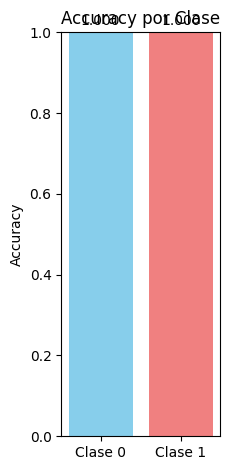

In [25]:
plt.subplot(1, 3, 3)
class_0_accuracy = np.sum((y_test == 0) & (y_pred == 0)) / np.sum(y_test == 0)
class_1_accuracy = np.sum((y_test == 1) & (y_pred == 1)) / np.sum(y_test == 1)
classes = ['Clase 0', 'Clase 1']
accuracies = [class_0_accuracy, class_1_accuracy]

bars = plt.bar(classes, accuracies, color=['skyblue', 'lightcoral'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Accuracy por Clase')

# Añadir valores en las barras
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 3. Fuentes de información

1. Hastie, T., Tibshirani, R., & Friedman, J. (2009). The Elements of Statistical Learning. Springer.
2. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). An Introduction to Statistical Learning. Springer.
3. Scikit-learn: Machine Learning in Python. Pedregosa et al., JMLR 12, pp. 2825-2830, 2011.
4. Bishop, C. M. (2006). Pattern Recognition and Machine Learning. Springer.